In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

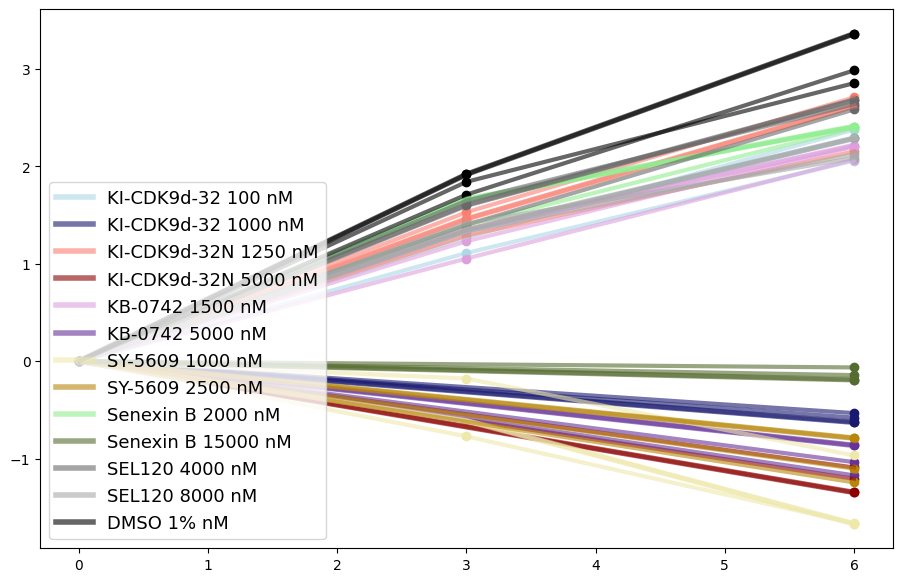

In [122]:
#df = pd.read_csv('2024_10_14_CBE.csv')
df = pd.read_csv('CDK_BE_cell_counts - CBE_screen.csv')
df = df[df['Days Post-Transduction']>8]

conditions = df[['Drug', 'Concentration (nM)']].drop_duplicates().reset_index().drop(columns='index')

conditions['color'] = [ 'lightblue', 'midnightblue',
 'salmon', 'darkred', 
  'plum','rebeccapurple',
 'palegoldenrod','darkgoldenrod', 
 'lightgreen','darkolivegreen', 
 'dimgrey', 'darkgrey', 'black']

fig, ax = plt.subplots(figsize=(11,7))

#drug = val['Drug']
#concentration = val['Concentration (nM)']
drug = 'KI-CDK9d-32'
concentration = '100'

base_amt = 2.75

for i, val in conditions.iterrows():
    drug = val['Drug']
    concentration = val['Concentration (nM)']
    subset = df[(df['Drug']==drug) & (df['Concentration (nM)']==concentration)]

    for i in range(1,4):
        rep = subset[subset['Replicate']==i]
        counts = np.asarray(rep['Cell Count (millions)'])
        pds = np.log2(counts/2.75)

        #print(str(list(rep['Cell Count (millions)'])[0]))
        if str(list(rep['Cell Count (millions)'])[0])=='nan':
            #print(drug)
            cpds = [0, pds[1]]
            t = np.asarray([8,14])-8
            
        
        else:
            cpds = [0, pds[0], pds[0]+pds[1]]
            t = np.asarray([8,11,14])-8
        
        if i==1:
            ax.plot(t, cpds, label=f'{drug} {concentration} nM', color=val['color'], linewidth=4, alpha=.6, 
                    )
            ax.scatter(t, cpds, color=val['color'])

        ax.plot(t, cpds, color=val['color'], linewidth=3, alpha=.6)
        #sns.lineplot(t, cpds,)
        ax.scatter(t, cpds, color=val['color'])


ax.legend(fontsize=13, loc='lower left')

/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

Text(0, 0.5, 'CPD')

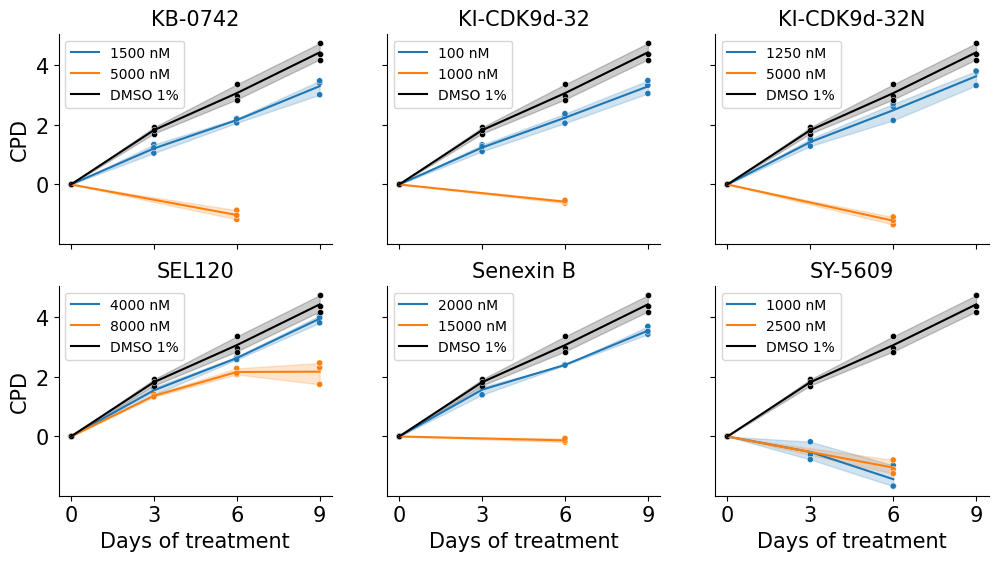

In [116]:
DMSO = df[(df['Drug']=='DMSO') & (df['Concentration (nM)']=='1%')]

DMSO_cpds = []
DMSO_t = []

for kk in range(1,4):
    rep = DMSO[DMSO['Replicate']==kk]
    counts = np.asarray(rep['Cell Count (millions)'])
    pds = np.log2(counts/2.75)

    cpds = [0, pds[0], pds[0]+pds[1], pds[0]+pds[1]+pds[2]]
    t = np.asarray([8,11,14, 17])-8

    for j in cpds:
        DMSO_cpds.append(j)
    for j in t:
        DMSO_t.append(j)

DMSO_df = pd.DataFrame(dict(zip(['Days of treatment', 'CPD'], [DMSO_t, DMSO_cpds])))


fig, ax = plt.subplots(2,3,figsize=(12,6), sharex=True, sharey=True)

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']
axs = [[0,0],[0,1], [0,2], [1,0], [1,1], [1,2]]

for i, val in enumerate(drugs):
    drug = val
    conc = np.unique(conditions[conditions['Drug']==drug]['Concentration (nM)'])
    conc = sorted([int(i) for i in conc])
    conc = [str(i) for i in conc]
    
    x = axs[i][0]
    y = axs[i][1]

    
    df_holder = []

    for k in conc:
        subset = df[(df['Drug']==drug) & (df['Concentration (nM)']==k)]
        
        cpds_comb = []
        t_comb = []

        for kk in range(1,4):
            rep = subset[subset['Replicate']==kk]
            counts = np.asarray(rep['Cell Count (millions)'])
            pds = np.log2(counts/2.75)

            #print(str(list(rep['Cell Count (millions)'])[0]))
            if str(list(rep['Cell Count (millions)'])[0])=='nan':
                #print(drug)
                cpds = [0, pds[1]]
                t = np.asarray([8,14])-8
                
            
            else:
                cpds = [0, pds[0], pds[0]+pds[1], pds[0]+pds[1]+pds[2]]
                t = np.asarray([8,11,14, 17])-8
            
            for j in cpds:
                cpds_comb.append(j)
            for j in t:
                t_comb.append(j)
            
        plot_df = pd.DataFrame(dict(zip(['Days of treatment', 'CPD'], [t_comb, cpds_comb])))
        plot_df['Concentration (nM)'] = f'{k} nM'
        df_holder.append(plot_df)
        
    df_plot = pd.concat(df_holder)

    if drug=='SY-5609':
        df_plot = df_plot[df_plot['Days of treatment']<9]

    sns.lineplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],);
    sns.scatterplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],  s=20, legend=False);
        
    ax[x][y].set_xticks([0,3,6, 9])
    ax[x][y].set_title(f'{drug}', fontsize=15)
    
    ax[x][y].spines[['right', 'top']].set_visible(False)
    ax[x][y].tick_params(axis='both', which='major', labelsize=15)

    sns.lineplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', label='DMSO 1%');
    sns.scatterplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', s=20);

    ax[x][y].legend(fontsize=10, loc='upper left')

    

ax[1][0].set_xlabel('Days of treatment', fontsize=15)
ax[1][1].set_xlabel('Days of treatment', fontsize=15)
ax[1][2].set_xlabel('Days of treatment', fontsize=15)
ax[0][0].set_ylabel('CPD', fontsize=15)
ax[1][0].set_ylabel('CPD', fontsize=15)



#sns.lineplot


In [115]:
df_plot

,Days of treatment,CPD,Concentration (nM)
0,0,0.000000,1000 nM
1,3,-0.611435,1000 nM
2,6,-1.670328,1000 nM
3,9,NaN,1000 nM
4,0,0.000000,1000 nM
5,3,-0.178475,1000 nM
6,6,-0.968880,1000 nM
7,9,NaN,1000 nM
8,0,0.000000,1000 nM
9,3,-0.772371,1000 nM


/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

<Axes: xlabel='Timepoint', ylabel='CPD'>

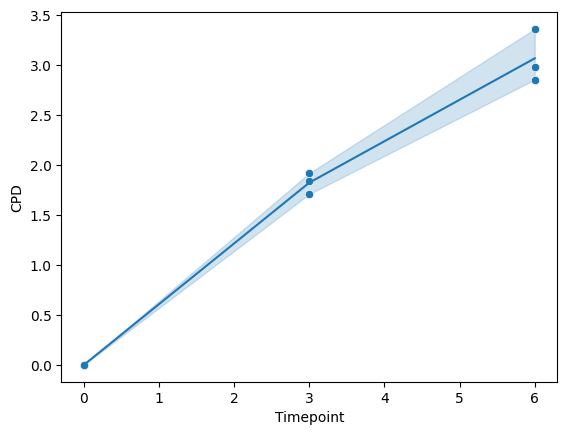

In [97]:
DMSO

DMSO_cpds = []
DMSO_t = []

for kk in range(1,4):
    rep = DMSO[DMSO['Replicate']==kk]
    counts = np.asarray(rep['Cell Count (millions)'])
    pds = np.log2(counts/2.75)

    cpds = [0, pds[0], pds[0]+pds[1]]
    t = np.asarray([8,11,14])-8

    for j in cpds:
        DMSO_cpds.append(j)
    for j in t:
        DMSO_t.append(j)

DMSO_df = pd.DataFrame(dict(zip(['Timepoint', 'CPD'], [DMSO_t, DMSO_cpds])))

sns.lineplot(DMSO_df, x='Timepoint', y='CPD')
sns.scatterplot(DMSO_df, x='Timepoint', y='CPD')

In [83]:
3%3

0

In [80]:
conditions

,Drug,Concentration (nM),color
0,KI-CDK9d-32,100,lightblue
1,KI-CDK9d-32,1000,midnightblue
2,KI-CDK9d-32N,1250,salmon
3,KI-CDK9d-32N,5000,darkred
4,KB-0742,1500,plum
5,KB-0742,5000,rebeccapurple
6,SY-5609,1000,palegoldenrod
7,SY-5609,2500,darkgoldenrod
8,Senexin B,2000,lightgreen
9,Senexin B,15000,darkolivegreen


In [57]:
conditions

conditions['color'] = [ 'lightblue', 'midnightblue',
 'salmon', 'darkred', 
  'plum','rebeccapurple',
 'palegoldenrod','darkgoldenrod', 
 'lightgreen','darkolivegreen', 
 'dimgrey', 'darkgrey', 'black']

conditions

,Drug,Concentration (nM),color
0,KI-CDK9d-32,100,lightblue
1,KI-CDK9d-32,1000,midnightblue
2,KI-CDK9d-32N,1250,salmon
3,KI-CDK9d-32N,5000,darkred
4,KB-0742,1500,plum
5,KB-0742,5000,rebeccapurple
6,SY-5609,1000,palegoldenrod
7,SY-5609,2500,darkgoldenrod
8,Senexin B,2000,lightgreen
9,Senexin B,15000,darkolivegreen


In [11]:
df['Concen']

,Date,Days Post-Transduction,Selection Agent,Drug,Concentration (nM),Replicate,Plate # /Format,Cell Count (millions),Cell Count Replated,# gDNA cell pellets,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
12,10/8/24,8,NONE,KI-CDK9d-32,100,1,1x 15-cm plate,2.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,10/8/24,8,NONE,KI-CDK9d-32,100,2,1x 15-cm plate,2.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,10/8/24,8,NONE,KI-CDK9d-32,100,3,1x 15-cm plate,2.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,10/8/24,8,NONE,KI-CDK9d-32,1000,1,1x 15-cm plate,2.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,10/8/24,8,NONE,KI-CDK9d-32,1000,2,1x 15-cm plate,2.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,10/14/24,14,NONE,SEL120,8000,2,1x 15-cm plate,4.38,2.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,10/14/24,14,NONE,SEL120,8000,3,1x 15-cm plate,4.77,2.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,10/14/24,14,NONE,DMSO,1%,1,1x 15-cm plate,7.48,2.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,10/14/24,14,NONE,DMSO,1%,2,1x 15-cm plate,6.66,2.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Redo the method for calculating CPDs

In [112]:
ABE = pd.read_csv('CDK_BE_cell_counts - ABE_screen.csv')
CBE = pd.read_csv('CDK_BE_cell_counts - CBE_screen.csv')

CBE = CBE[CBE['Days Post-Transduction']>=8]
ABE = ABE[ABE['Days Post-Transduction']>=8]

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']

conditions = CBE[['Drug', 'Concentration (nM)']].drop_duplicates().reset_index().drop(columns='index')
conditions




,Drug,Concentration (nM)
0,KI-CDK9d-32,100
1,KI-CDK9d-32,1000
2,KI-CDK9d-32N,1250
3,KI-CDK9d-32N,5000
4,KB-0742,1500
5,KB-0742,5000
6,SY-5609,1000
7,SY-5609,2500
8,Senexin B,2000
9,Senexin B,15000


In [113]:
def CPD_calc(df, conditions):
    df_holder = []
    for i, val in conditions.iterrows():
        drug = val['Drug']
        conc = val['Concentration (nM)']

        subset1 = df[(df['Drug']==drug) & (df['Concentration (nM)']==conc)]

        for replicate in range(1,4):
            replicate = replicate
            subset2 = subset1[subset1['Replicate']==replicate]

            count = list(subset2['Cell Count (millions)'])
            count_replated = list(subset2['Cell Count Replated'])
            t = list(subset2['Days Post-Treatment'])

            popds = [0]
            cpds = [0]
            time = [0]

            for i, val in enumerate(t):
                if i>0:
                    if str(count[i])=='nan':
                        continue
                    else:
                        if len(popds)==1:
                            popd = np.log2(count[i]/2.75)
                        else:
                            if str(count_replated[i-1])=='nan':
                            
                                popd = np.log2(count[i]/count_replated[i-2])
                            else:
                                popd = np.log2(count[i]/count_replated[i-1])

                        popds.append(popd)
                        time.append(val)
                        
                        
                        
                else:
                    continue

            for i, val in enumerate(popds):
                if i==0:
                    continue
                else:
                    cpds.append(val + cpds[i-1])

            plot_df = pd.DataFrame(dict(zip(['Days of treatment', 'PD', 'CPD'], [time, popds, cpds])))
            plot_df['Concentration (nM)'] = f'{conc} nM'
            plot_df['Drug'] = drug
            plot_df['Replicate'] = replicate

            df_holder.append(plot_df)


    return pd.concat(df_holder)

In [114]:
CBE_CPD = CPD_calc(CBE, conditions)
ABE_CPD = CPD_calc(ABE, conditions)

In [115]:
ABE[(ABE['Drug']=='KI-CDK9d-32') & ((ABE['Concentration (nM)']=='1000')) & (ABE['Replicate']==1)]

,Date,Days Post-Transduction,Days Post-Treatment,Selection Agent,Drug,Concentration (nM),Actual concentration replated (nM),Replicate,Plate # /Format,Cell Count (millions),Cell Count Replated,# gDNA cell pellets,gDNA pellet cell count (millions),RFP+ %,Notes
12,10/15/24,8,0.0,NONE,KI-CDK9d-32,1000,1000,1,1x 15-cm plate,2.75,NaN,NaN,NaN,NaN,NaN
51,10/18/24,11,3.0,NONE,KI-CDK9d-32,1000,1000,1,1x 15-cm plate,2.91,2.75,1.0,2.75,NaN,NaN
90,10/21/24,14,6.0,NONE,KI-CDK9d-32,1000,0,1,1x 15-cm plate,1.79,1.79,NaN,NaN,NaN,NaN
129,10/24/24,17,9.0,NONE,KI-CDK9d-32,1000,0,1,1x 15-cm plate,2.24,2.24,NaN,NaN,NaN,NaN
168,10/27/24,20,12.0,NONE,KI-CDK9d-32,1000,200,1,1x 15-cm plate,6.39,2.75,1.0,2.75,NaN,NaN
207,10/30/24,23,15.0,NONE,KI-CDK9d-32,1000,200,1,1x 15-cm plate,4.88,2.75,1.0,2.75,NaN,NaN
246,11/2/24,26,18.0,NONE,KI-CDK9d-32,1000,200,1,1x 15-cm plate,6.16,2.75,1.0,2.75,NaN,NaN
285,11/5/24,29,21.0,NONE,KI-CDK9d-32,1000,200,1,1x 15-cm plate,6.47,NaN,2.0,2.75,NaN,NaN


In [116]:
np.log2(10/2.75)

1.862496476250065

/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

Text(0, 0.5, 'CPD')

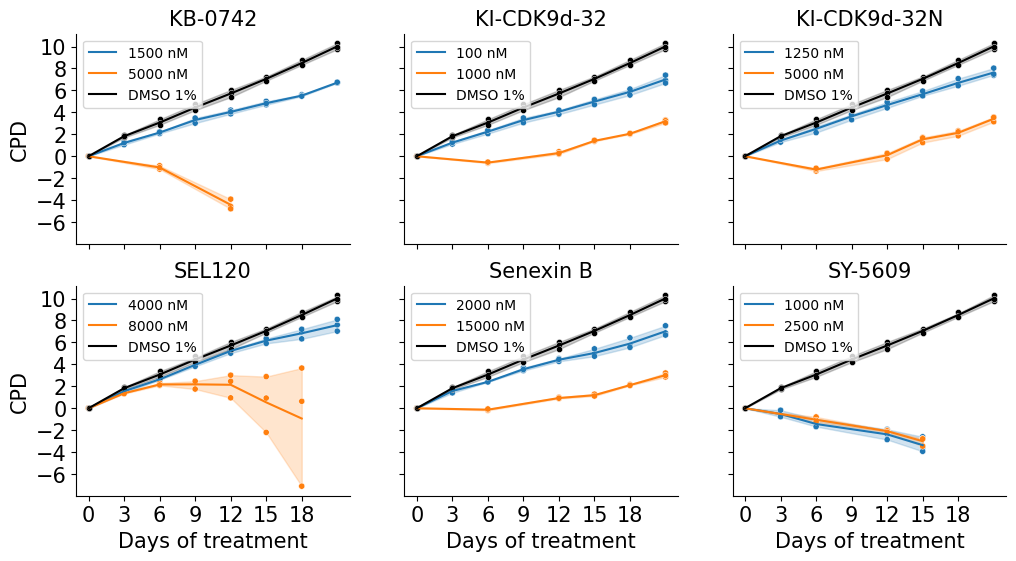

In [117]:
fig, ax = plt.subplots(2,3,figsize=(12,6), sharex=True, sharey=True)

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']
axs = [[0,0],[0,1], [0,2], [1,0], [1,1], [1,2]]

DMSO_df = CBE_CPD[CBE_CPD['Drug']=='DMSO']

for i, val in enumerate(drugs):
    df_plot = CBE_CPD[CBE_CPD['Drug']==val]
    
    x = axs[i][0]
    y = axs[i][1]
    
    sns.lineplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],);
    sns.scatterplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],  s=20, legend=False);
        
    ax[x][y].set_xticks([0,3,6, 9, 12, 15, 18])
    ax[x][y].set_yticks([-6,-4,-2,0,2,4,6,8,10])
    ax[x][y].set_title(f'{val}', fontsize=15)
    
    ax[x][y].spines[['right', 'top']].set_visible(False)
    ax[x][y].tick_params(axis='both', which='major', labelsize=15)


    #and then plot DMSO on top
    sns.lineplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', label='DMSO 1%');
    sns.scatterplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', s=20);

    ax[x][y].legend(fontsize=10, loc='upper left')

    

ax[1][0].set_xlabel('Days of treatment', fontsize=15)
ax[1][1].set_xlabel('Days of treatment', fontsize=15)
ax[1][2].set_xlabel('Days of treatment', fontsize=15)
ax[0][0].set_ylabel('CPD', fontsize=15)
ax[1][0].set_ylabel('CPD', fontsize=15)


/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

Text(0, 0.5, 'CPD')

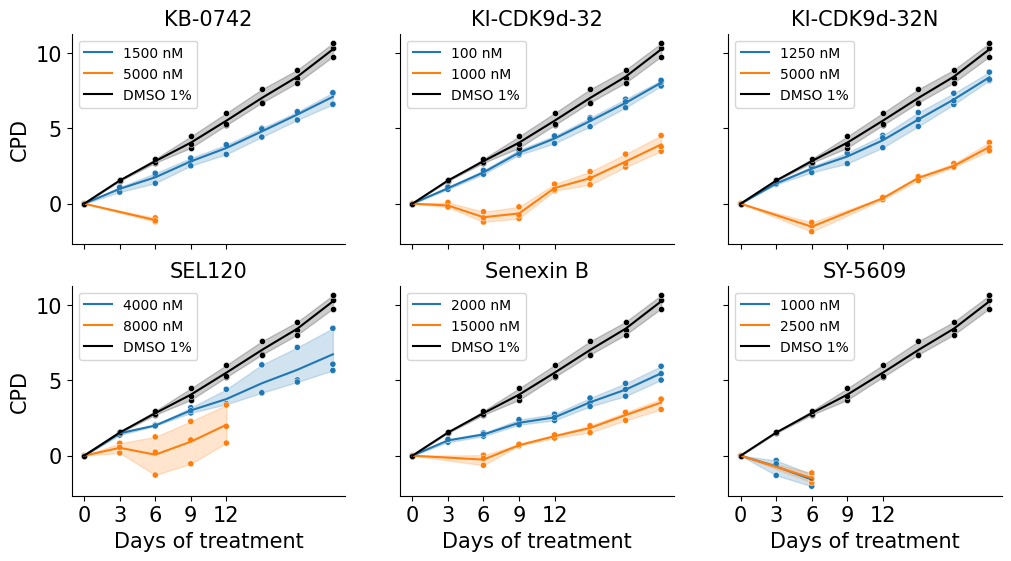

In [118]:
fig, ax = plt.subplots(2,3,figsize=(12,6), sharex=True, sharey=True)

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']
axs = [[0,0],[0,1], [0,2], [1,0], [1,1], [1,2]]

DMSO_df = ABE_CPD[ABE_CPD['Drug']=='DMSO']

for i, val in enumerate(drugs):
    df_plot = ABE_CPD[ABE_CPD['Drug']==val]
    
    x = axs[i][0]
    y = axs[i][1]
    
    sns.lineplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],);
    sns.scatterplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],  s=20, legend=False);
        
    ax[x][y].set_xticks([0,3,6, 9, 12])
    ax[x][y].set_title(f'{val}', fontsize=15)
    
    ax[x][y].spines[['right', 'top']].set_visible(False)
    ax[x][y].tick_params(axis='both', which='major', labelsize=15)


    #and then plot DMSO on top
    sns.lineplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', label='DMSO 1%');
    sns.scatterplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', s=20);

    ax[x][y].legend(fontsize=10, loc='upper left')

    

ax[1][0].set_xlabel('Days of treatment', fontsize=15)
ax[1][1].set_xlabel('Days of treatment', fontsize=15)
ax[1][2].set_xlabel('Days of treatment', fontsize=15)
ax[0][0].set_ylabel('CPD', fontsize=15)
ax[1][0].set_ylabel('CPD', fontsize=15)

#fig.savefig('ABE_CPD.pdf')

In [108]:
ABE_CPD[ABE_CPD['Drug']=='SEL120']

,Days of treatment,PD,CPD,Concentration (nM),Drug,Replicate
0,0.0,0.000000,0.000000,4000 nM,SEL120,1
1,3.0,1.542371,1.542371,4000 nM,SEL120,1
2,6.0,0.500339,2.042709,4000 nM,SEL120,1
3,9.0,0.797579,2.840288,4000 nM,SEL120,1
4,12.0,0.572669,3.412957,4000 nM,SEL120,1
5,15.0,0.803603,4.216560,4000 nM,SEL120,1
0,0.0,0.000000,0.000000,4000 nM,SEL120,2
1,3.0,1.368387,1.368387,4000 nM,SEL120,2
2,6.0,0.624633,1.993020,4000 nM,SEL120,2
3,9.0,1.193628,3.186648,4000 nM,SEL120,2


# adding info about dosing

/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

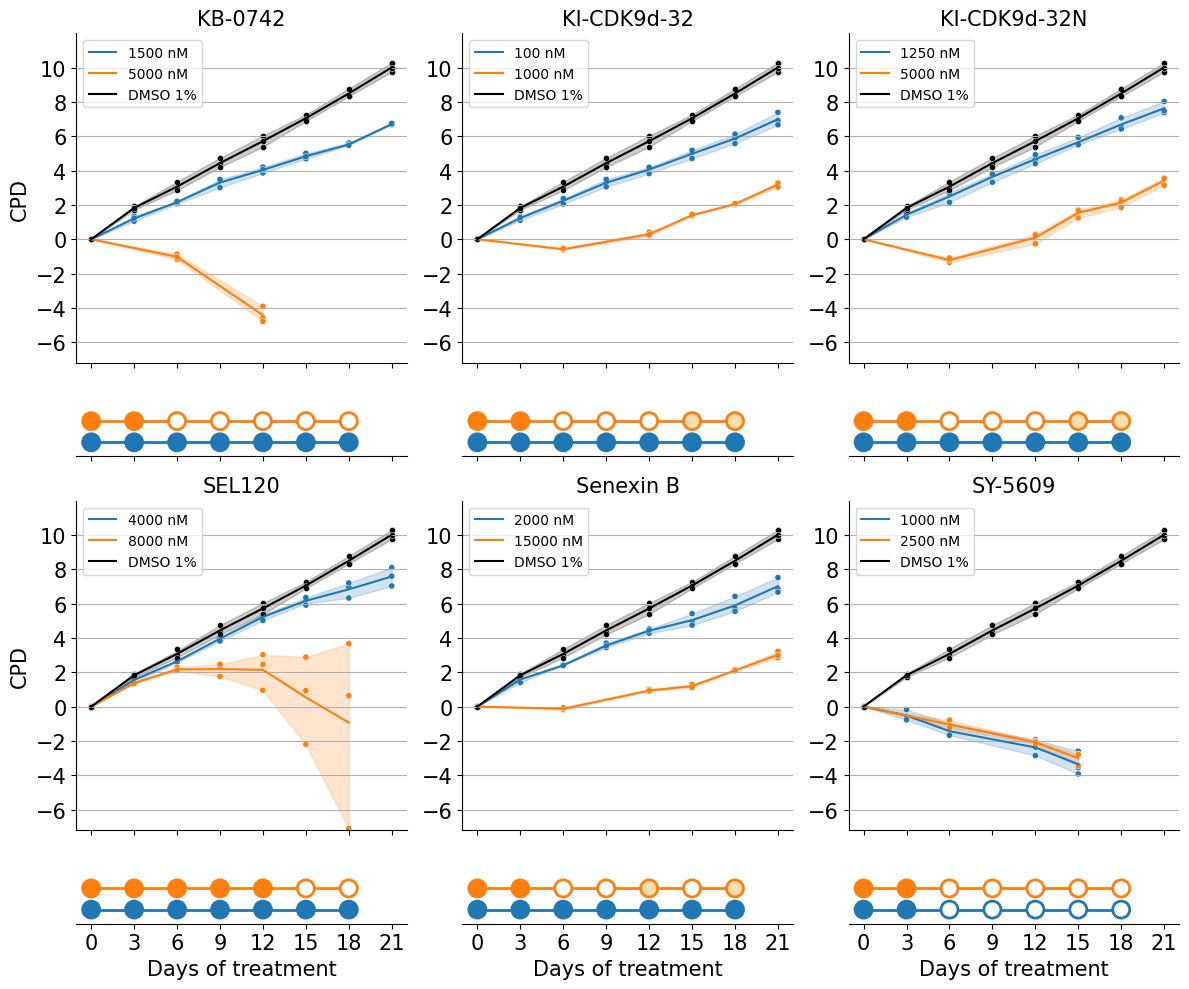

In [124]:
fig, ax = plt.subplots(4,3,figsize=(12,10), sharex=True, sharey=False, height_ratios=[1,.15, 1, .15])

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']
axs = [[0,0],[0,1], [0,2], [2,0], [2,1], [2,2]]

DMSO_df = CBE_CPD[CBE_CPD['Drug']=='DMSO']

for i, val in enumerate(drugs):
    df_plot = CBE_CPD[CBE_CPD['Drug']==val]
    
    x = axs[i][0]
    y = axs[i][1]
    
    sns.lineplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],);
    sns.scatterplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],  s=20, legend=False);
        
    ax[x][y].set_xticks([0,3,6, 9, 12, 15, 18,21])
    ax[x][y].set_yticks([-6,-4,-2,0,2,4,6,8,10])
    ax[x][y].set_ylim(-7.2,12)
    
    ax[x][y].set_title(f'{val}', fontsize=15)
    
    ax[x][y].spines[['right', 'top']].set_visible(False)
    ax[x][y].tick_params(axis='both', which='major', labelsize=15)

    #and then plot DMSO on top
    sns.lineplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', label='DMSO 1%');
    sns.scatterplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', s=20);

    ax[x][y].set_ylabel('')
    ax[x][y].legend(fontsize=10, loc='upper left')
    ax[x][y].yaxis.grid()

    concentrations = np.unique(list(conditions[conditions['Drug']==val]['Concentration (nM)']))
    concentrations = sorted([int(j) for j in concentrations])
    for idx, k in enumerate(concentrations):
        x = axs[i][0]+1
        y = y
        subset = CBE[(CBE['Concentration (nM)']==str(k)) & (CBE['Drug']==val) & (CBE['Replicate']==1)]

        times = list(subset['Days Post-Treatment'])[:-1]
        listed = list(subset['Concentration (nM)'])[:-1]
        act = list(subset['Actual concentration replated (nM)'])[:-1]

        fill_color = []
        for jj, val2 in enumerate(listed):
            if val2 ==act[jj]:
                if idx==0:
                    fill_color.append('tab:blue')
                if idx==1:
                    fill_color.append('tab:orange')
            elif act[jj]=='0':
                fill_color.append('white')
            elif int(val2)>int(act[jj]):
                if idx==0:
                    fill_color.append('lightblue')
                if idx==1:
                    fill_color.append('navajowhite')

        if idx==0:
            ax[x][y].plot(times, [0]*len(times), linewidth=2, color='tab:blue', zorder=1)
            ax[x][y].scatter(times, [0]*len(times), linewidth=2, edgecolors='tab:blue', c=fill_color, s=150, zorder=2)
            ax[x][y].spines[['right', 'top', 'left']].set_visible(False)
            ax[x][y].set_yticks([])
            ax[x][y].tick_params(axis='both', which='major', labelsize=15)
        if idx==1:
            ax[x][y].plot(times, [3]*len(times), linewidth=2, color='tab:orange', zorder=1)
            ax[x][y].scatter(times, [3]*len(times), linewidth=2, edgecolors='tab:orange', c=fill_color, s=150, zorder=2)
            ax[x][y].spines[['right', 'top', 'left']].set_visible(False)
            ax[x][y].set_yticks([])
            ax[x][y].tick_params(axis='both', which='major', labelsize=15)
        
        ax[x][y].set_ylim(-2,5)

ax[3][0].set_xlabel('Days of treatment', fontsize=15)
ax[3][1].set_xlabel('Days of treatment', fontsize=15)
ax[3][2].set_xlabel('Days of treatment', fontsize=15)
ax[0][0].set_ylabel('CPD', fontsize=15)
ax[2][0].set_ylabel('CPD', fontsize=15)

#fig.subplots_adjust(hspace=0)
fig.tight_layout()
fig.savefig('CBE_CPD_final.pdf')

/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/samgould/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

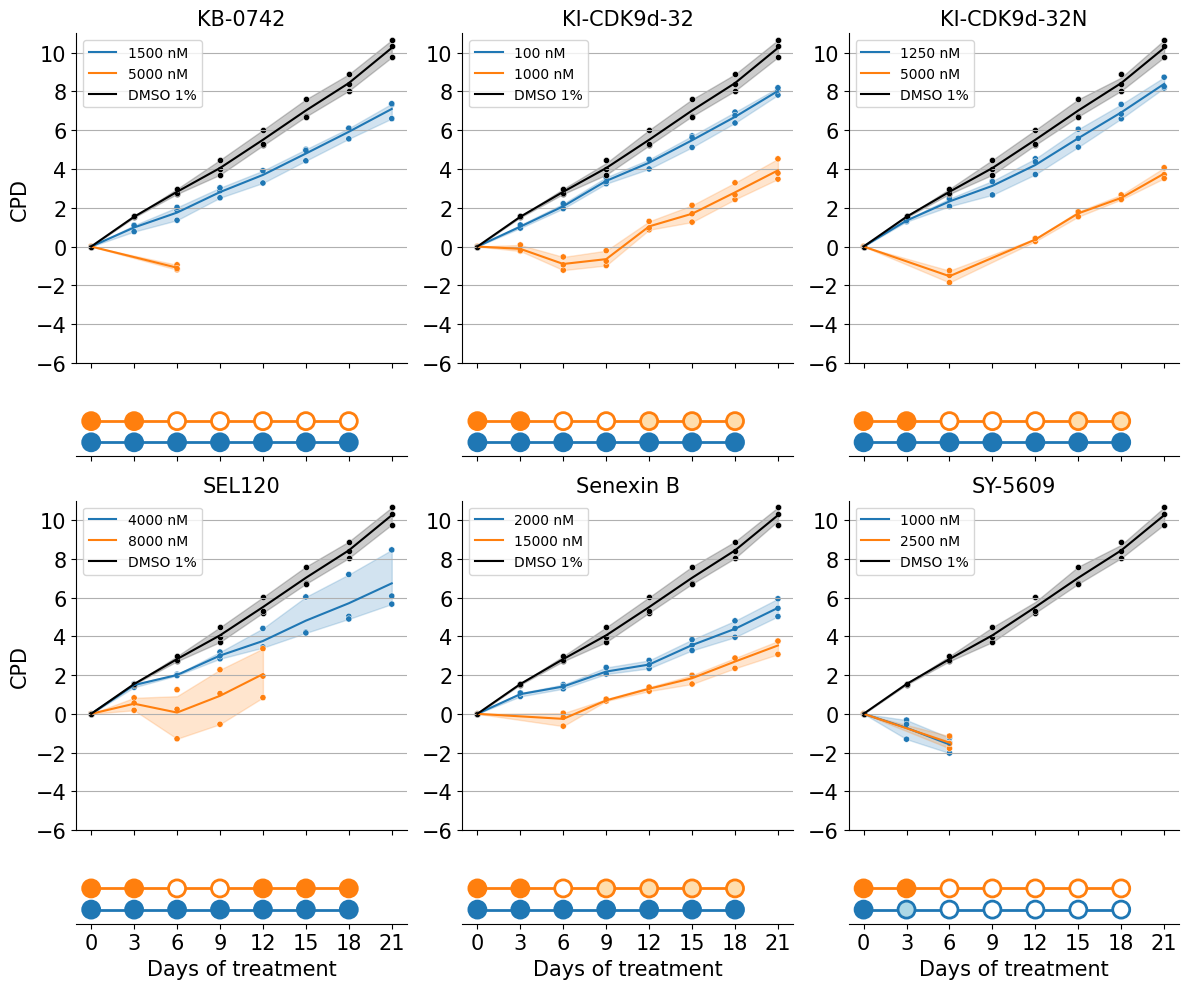

In [126]:
fig, ax = plt.subplots(4,3,figsize=(12,10), sharex=True, sharey=False, height_ratios=[1,.15, 1, .15])

drugs = ['KB-0742', 'KI-CDK9d-32', 'KI-CDK9d-32N', 'SEL120','Senexin B','SY-5609']
axs = [[0,0],[0,1], [0,2], [2,0], [2,1], [2,2]]

DMSO_df = ABE_CPD[ABE_CPD['Drug']=='DMSO']

for i, val in enumerate(drugs):
    df_plot = ABE_CPD[ABE_CPD['Drug']==val]
    
    x = axs[i][0]
    y = axs[i][1]
    
    sns.lineplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],);
    sns.scatterplot(df_plot, x='Days of treatment', y='CPD', hue='Concentration (nM)', ax=ax[x][y],  s=20, legend=False);
        
    ax[x][y].set_xticks([0,3,6, 9, 12, 15, 18,21])
    ax[x][y].set_yticks([-6,-4,-2,0,2,4,6,8,10])
    ax[x][y].set_ylim(-6,11)
    
    ax[x][y].set_title(f'{val}', fontsize=15)
    
    ax[x][y].spines[['right', 'top']].set_visible(False)
    ax[x][y].tick_params(axis='both', which='major', labelsize=15)

    #and then plot DMSO on top
    sns.lineplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', label='DMSO 1%');
    sns.scatterplot(DMSO_df, x='Days of treatment', y='CPD', ax=ax[x][y], color='black', s=20);

    ax[x][y].set_ylabel('')
    ax[x][y].legend(fontsize=10, loc='upper left')
    ax[x][y].yaxis.grid()

    concentrations = np.unique(list(conditions[conditions['Drug']==val]['Concentration (nM)']))
    concentrations = sorted([int(j) for j in concentrations])
    for idx, k in enumerate(concentrations):
        x = axs[i][0]+1
        y = y
        subset = ABE[(ABE['Concentration (nM)']==str(k)) & (ABE['Drug']==val) & (ABE['Replicate']==1)]

        times = list(subset['Days Post-Treatment'])[:-1]
        listed = list(subset['Concentration (nM)'])[:-1]
        act = list(subset['Actual concentration replated (nM)'])[:-1]

        fill_color = []
        for jj, val2 in enumerate(listed):
            if val2 ==act[jj]:
                if idx==0:
                    fill_color.append('tab:blue')
                if idx==1:
                    fill_color.append('tab:orange')
            elif act[jj]=='0':
                fill_color.append('white')
            elif int(val2)>int(act[jj]):
                if idx==0:
                    fill_color.append('lightblue')
                if idx==1:
                    fill_color.append('navajowhite')

        if idx==0:
            ax[x][y].plot(times, [0]*len(times), linewidth=2, color='tab:blue', zorder=1)
            ax[x][y].scatter(times, [0]*len(times), linewidth=2, edgecolors='tab:blue', c=fill_color, s=150, zorder=2)
            ax[x][y].spines[['right', 'top', 'left']].set_visible(False)
            ax[x][y].set_yticks([])
            ax[x][y].tick_params(axis='both', which='major', labelsize=15)
        if idx==1:
            ax[x][y].plot(times, [3]*len(times), linewidth=2, color='tab:orange', zorder=1)
            ax[x][y].scatter(times, [3]*len(times), linewidth=2, edgecolors='tab:orange', c=fill_color, s=150, zorder=2)
            ax[x][y].spines[['right', 'top', 'left']].set_visible(False)
            ax[x][y].set_yticks([])
            ax[x][y].tick_params(axis='both', which='major', labelsize=15)
        
        ax[x][y].set_ylim(-2,5)

ax[3][0].set_xlabel('Days of treatment', fontsize=15)
ax[3][1].set_xlabel('Days of treatment', fontsize=15)
ax[3][2].set_xlabel('Days of treatment', fontsize=15)
ax[0][0].set_ylabel('CPD', fontsize=15)
ax[2][0].set_ylabel('CPD', fontsize=15)

fig.tight_layout()
fig.savefig('ABE_CPDv2.pdf')